# Етап 1. Дослідження даних і підготовка

Цільова змінна — SalePrice


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

np.random.seed(42)
plt.rcParams["figure.figsize"] = (8, 4.5)


## 1.1 Первинний аналіз


In [6]:
DATA_URL = (
    "https://raw.githubusercontent.com/rasbt/machine-learning-book/"
    "main/ch09/AmesHousing.txt"
)

df = pd.read_csv(DATA_URL, sep="\t")
print("Розмір:", df.shape)
df.head()


Розмір: (2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [7]:
print(df.describe())

            Order           PID  MS SubClass  Lot Frontage       Lot Area  \
count  2930.00000  2.930000e+03  2930.000000   2440.000000    2930.000000   
mean   1465.50000  7.144645e+08    57.387372     69.224590   10147.921843   
std     845.96247  1.887308e+08    42.638025     23.365335    7880.017759   
min       1.00000  5.263011e+08    20.000000     21.000000    1300.000000   
25%     733.25000  5.284770e+08    20.000000     58.000000    7440.250000   
50%    1465.50000  5.354536e+08    50.000000     68.000000    9436.500000   
75%    2197.75000  9.071811e+08    70.000000     80.000000   11555.250000   
max    2930.00000  1.007100e+09   190.000000    313.000000  215245.000000   

       Overall Qual  Overall Cond   Year Built  Year Remod/Add  Mas Vnr Area  \
count   2930.000000   2930.000000  2930.000000     2930.000000   2907.000000   
mean       6.094881      5.563140  1971.356314     1984.266553    101.896801   
std        1.411026      1.111537    30.245361       20.860286    

In [8]:
# Order and PID are transaction ids, not features.
# MS SubClass is a dwelling code, not a magnitude.
id_columns = ["Order", "PID"]
coded_as_category = ["MS SubClass"]

numeric_all = [
    column
    for column in df.select_dtypes(include="number").columns
    if column not in id_columns + coded_as_category + ["SalePrice"]
]
categorical_all = df.select_dtypes(exclude="number").columns.tolist()

print(f"Числових ознак (без id і SalePrice): {len(numeric_all)}")
print(f"Категоріальних ознак: {len(categorical_all)}")
print(f"Кодів, які не трактую як число: {coded_as_category}")


Числових ознак (без id і SalePrice): 35
Категоріальних ознак: 43
Кодів, які не трактую як число: ['MS SubClass']


### Пропуски


                пропусків  частка, %
Pool QC              2917       99.6
Misc Feature         2824       96.4
Alley                2732       93.2
Fence                2358       80.5
Mas Vnr Type         1775       60.6
Fireplace Qu         1422       48.5
Lot Frontage          490       16.7
Garage Qual           159        5.4
Garage Cond           159        5.4
Garage Yr Blt         159        5.4
Garage Finish         159        5.4
Garage Type           157        5.4
Bsmt Exposure          83        2.8
BsmtFin Type 2         81        2.8
Bsmt Cond              80        2.7


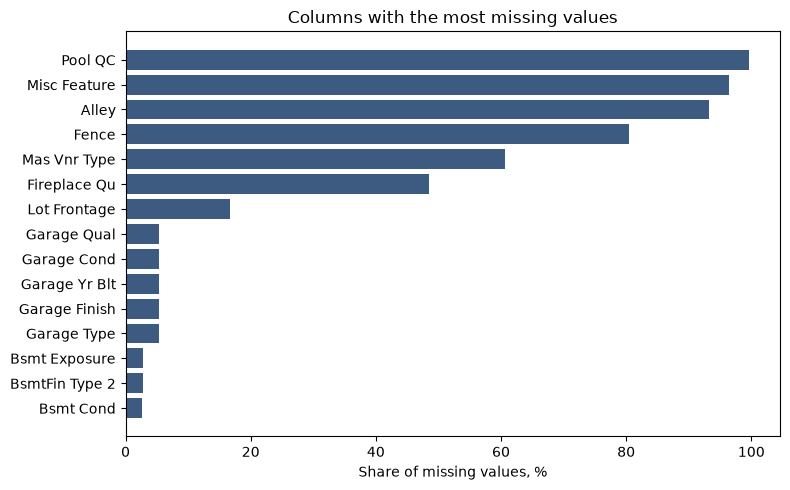

In [9]:
missing_counts = df.isna().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)
missing_share = (missing_counts / len(df) * 100).round(1)
missing_table = pd.DataFrame({"пропусків": missing_counts, "частка, %": missing_share})
print(missing_table.head(15))

top_missing = missing_table.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_missing.index, top_missing["частка, %"], color="#3d5a80")
ax.set_xlabel("Share of missing values, %")
ax.set_title("Columns with the most missing values")
fig.tight_layout()
plt.show()


**Висновок.** `Pool QC`, `Alley`, `Fence`, `Misc Feature` майже порожні: у цих даних пропуск зазвичай означає, що об'єкта немає. У модель їх не беру. Рідкі пропуски в числових колонках заповню медіаною Train.


### SalePrice


count      2930.0
mean     180796.1
std       79886.7
min       12789.0
25%      129500.0
50%      160000.0
75%      213500.0
max      755000.0
Name: SalePrice, dtype: float64
Асиметрія: 1.744


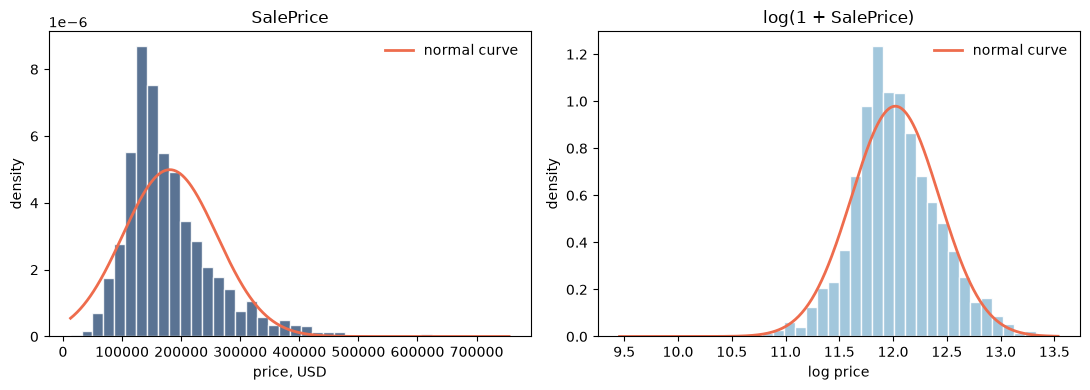

In [10]:
price = df["SalePrice"]
log_price = np.log1p(price)
print(price.describe().round(1))
print("Асиметрія:", round(float(price.skew()), 3))


def normal_curve(values, ax):
    values = np.asarray(values, dtype=float)
    mu = values.mean()
    sigma = values.std(ddof=1)
    xs = np.linspace(values.min(), values.max(), 400)
    pdf = np.exp(-0.5 * ((xs - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))
    ax.plot(xs, pdf, color="#ee6c4d", linewidth=2, label="normal curve")
    ax.legend(frameon=False)


fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(price, bins=40, density=True, color="#3d5a80", edgecolor="white", alpha=0.85)
normal_curve(price, axes[0])
axes[0].set_title("SalePrice")
axes[0].set_xlabel("price, USD")
axes[0].set_ylabel("density")

axes[1].hist(log_price, bins=40, density=True, color="#98c1d9", edgecolor="white", alpha=0.9)
normal_curve(log_price, axes[1])
axes[1].set_title("log(1 + SalePrice)")
axes[1].set_xlabel("log price")
axes[1].set_ylabel("density")
fig.tight_layout()
plt.show()


**Висновок.** Сира ціна не збігається з нормальною кривою: правий хвіст, асиметрія ≈ 1.7. Після логарифма розподіл уже близький до нормального. У модель лишаю долари, щоб коефіцієнт читався як зміна ціни.


       Overall Qual  Gr Liv Area  Year Built  Total Bsmt SF  Garage Cars  \
count        2930.0       2930.0      2930.0         2929.0       2929.0   
mean            6.1       1499.7      1971.4         1051.6          1.8   
std             1.4        505.5        30.2          440.6          0.8   
min             1.0        334.0      1872.0            0.0          0.0   
25%             5.0       1126.0      1954.0          793.0          1.0   
50%             6.0       1442.0      1973.0          990.0          2.0   
75%             7.0       1742.8      2001.0         1302.0          2.0   
max            10.0       5642.0      2010.0         6110.0          5.0   

       SalePrice  
count     2930.0  
mean    180796.1  
std      79886.7  
min      12789.0  
25%     129500.0  
50%     160000.0  
75%     213500.0  
max     755000.0  

Gr Liv Area > 4000: 5 rows


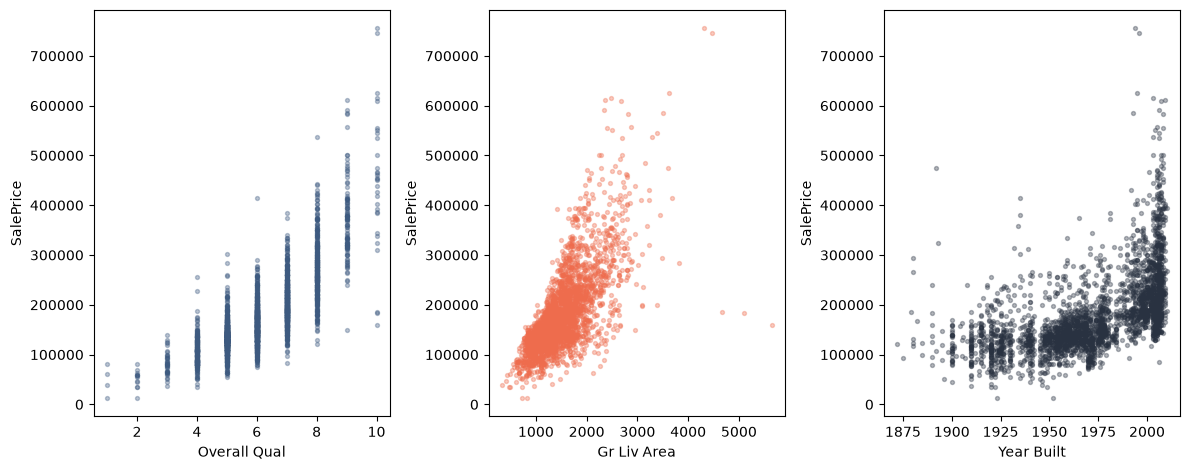

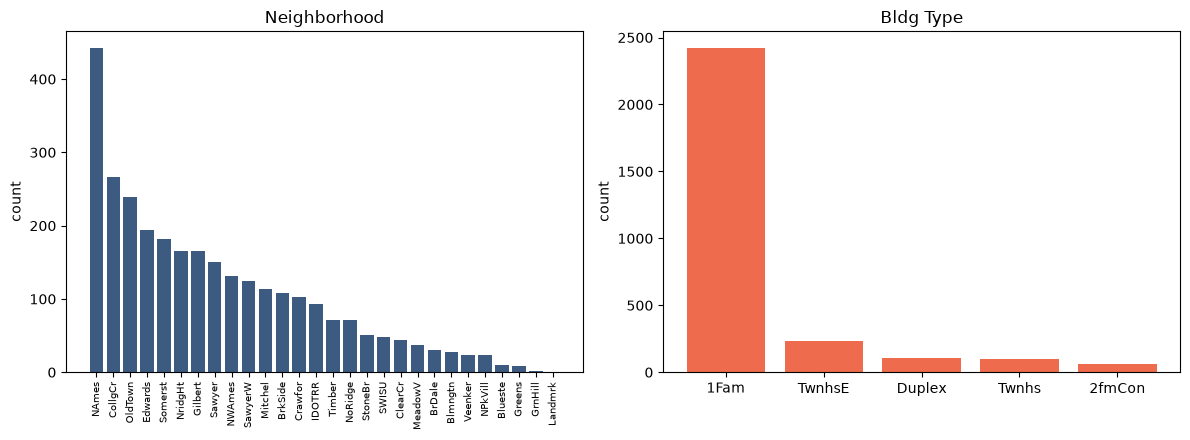

In [11]:
preview_columns = [
    "Overall Qual", "Gr Liv Area", "Year Built",
    "Total Bsmt SF", "Garage Cars", "SalePrice",
]
print(df[preview_columns].describe().round(1))
print("\nGr Liv Area > 4000:", int((df["Gr Liv Area"] > 4000).sum()), "rows")

fig, axes = plt.subplots(1, 3, figsize=(12, 4.8))
for ax, column, color in zip(
    axes,
    ["Overall Qual", "Gr Liv Area", "Year Built"],
    ["#3d5a80", "#ee6c4d", "#293241"],
):
    ax.scatter(df[column], df["SalePrice"], s=8, alpha=0.35, color=color)
    ax.set_xlabel(column)
    ax.set_ylabel("SalePrice")
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
neighborhood_counts = df["Neighborhood"].value_counts()
axes[0].bar(range(len(neighborhood_counts)), neighborhood_counts.values, color="#3d5a80")
axes[0].set_xticks(range(len(neighborhood_counts)), neighborhood_counts.index, rotation=90, fontsize=7)
axes[0].set_ylabel("count")
axes[0].set_title("Neighborhood")
bldg_counts = df["Bldg Type"].value_counts()
axes[1].bar(bldg_counts.index.astype(str), bldg_counts.values, color="#ee6c4d")
axes[1].set_ylabel("count")
axes[1].set_title("Bldg Type")
fig.tight_layout()
plt.show()


**Висновок.** Ціна зростає разом із якістю і житловою площею. З роком побудови зв'язок слабший.

Кілька будинків мають `Gr Liv Area` > 4000 і дуже високу або навпаки підозріло низьку ціну — це викиди, які пізніше тягнуть залишки на краях. Райони розподілені нерівномірно: кілька великих і багато малих. `Bldg Type` майже весь — односімейні будинки (`1Fam`).


## 1.2 Розбиття вибірки

Чому розбиття стоїть перед відбором ознак, масштабуванням і кодуванням. Кореляція, середнє, стандартне відхилення і список категорій оцінюються з даних. Якщо порахувати їх на всій таблиці, тестові рядки вже вплинули на підготовку моделі. Це витік даних: помилка на тесті виходить меншою, ніж буде на нових будинках.

Вибірку ділю на 60 відсотків Train, 20 відсотків Validation і 20 відсотків Test. Кореляції для відбору, медіану пропусків, кодувальник і стандартизацію рахую тільки на Train.


In [12]:
X = df.drop(columns=["SalePrice"])
y = df["SalePrice"].astype(float)

X_train, X_rest, y_train, y_rest = train_test_split(
    X, y, test_size=0.4, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_rest, y_rest, test_size=0.5, random_state=42
)

print("Train:", X_train.shape, "Validation:", X_val.shape, "Test:", X_test.shape)


Train: (1758, 81) Validation: (586, 81) Test: (586, 81)


## 1.3 Відбір ознак

Числові ознаки відбираю тільки на Train. Залишаю ті, у яких модуль кореляції Пірсона з SalePrice не нижче 0.5. Якщо дві ознаки корелюють між собою на 0.8 або сильніше, залишаю ту, що сильніше пов'язана з ціною.

MS SubClass у цю кореляцію не включаю, бо це код типу житла, а не величина.


Кореляція з SalePrice на Train, топ-12:
Overall Qual      0.791
Gr Liv Area       0.704
Garage Cars       0.642
Total Bsmt SF     0.642
Garage Area       0.631
1st Flr SF        0.624
Year Built        0.543
Full Bath         0.543
Mas Vnr Area      0.512
Year Remod/Add    0.511
Garage Yr Blt     0.511
TotRms AbvGrd     0.490
dtype: float64


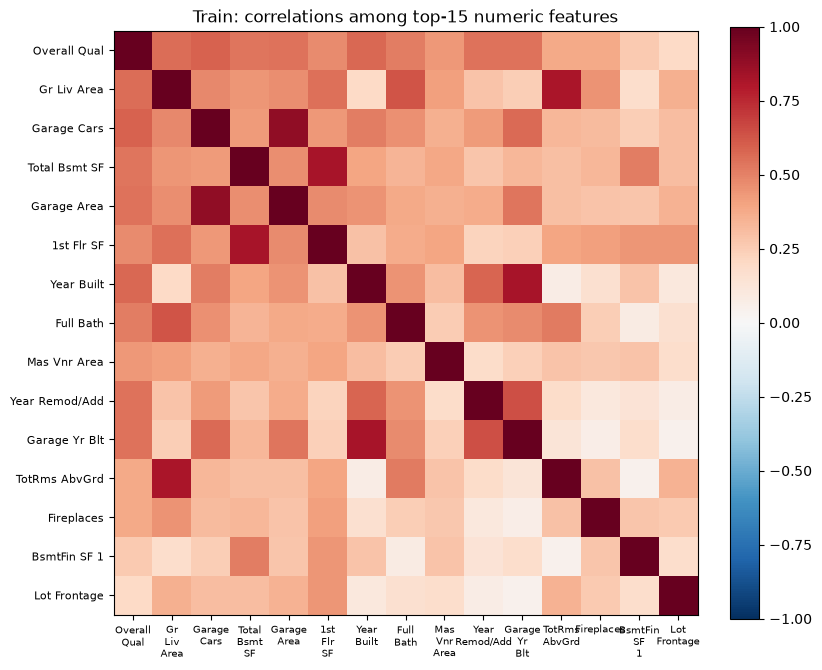


Залишені числові ознаки: ['Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Total Bsmt SF', 'Year Built', 'Full Bath', 'Mas Vnr Area', 'Year Remod/Add']
Прибрані через сильну парну кореляцію:
  Garage Area ~ Garage Cars: r = 0.890
  1st Flr SF ~ Total Bsmt SF: r = 0.828
  Garage Yr Blt ~ Year Built: r = 0.823


In [13]:
# Correlation is computed before missing values are filled.
corr_with_price = (
    X_train[numeric_all]
    .corrwith(y_train)
    .sort_values(key=lambda series: series.abs(), ascending=False)
)
print("Кореляція з SalePrice на Train, топ-12:")
print(corr_with_price.head(12).round(3))

# Full correlation matrix of top-15 numeric features (before |r|>=0.5 filter).
top15 = corr_with_price.head(15).index.tolist()
full_matrix = X_train[top15].corr()
fig, ax = plt.subplots(figsize=(9.5, 8))
image = ax.imshow(full_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(top15)), [name.replace(" ", "\n") for name in top15], fontsize=7)
ax.set_yticks(range(len(top15)), top15, fontsize=8)
fig.colorbar(image, ax=ax, fraction=0.046)
ax.set_title("Train: correlations among top-15 numeric features")
fig.subplots_adjust(left=0.22, right=0.9, bottom=0.18, top=0.92)
plt.show()

candidates = corr_with_price[corr_with_price.abs() >= 0.5]
candidate_matrix = X_train[candidates.index].corr()

selected_numeric = []
dropped_pairs = []
for column in candidates.abs().sort_values(ascending=False).index:
    if not selected_numeric:
        selected_numeric.append(column)
        continue
    pair_corr = candidate_matrix.loc[column, selected_numeric].abs()
    if (pair_corr >= 0.8).any():
        rival = pair_corr.idxmax()
        dropped_pairs.append((column, rival, float(pair_corr.max())))
    else:
        selected_numeric.append(column)

print("\nЗалишені числові ознаки:", selected_numeric)
print("Прибрані через сильну парну кореляцію:")
for column, rival, value in dropped_pairs:
    print(f"  {column} ~ {rival}: r = {value:.3f}")


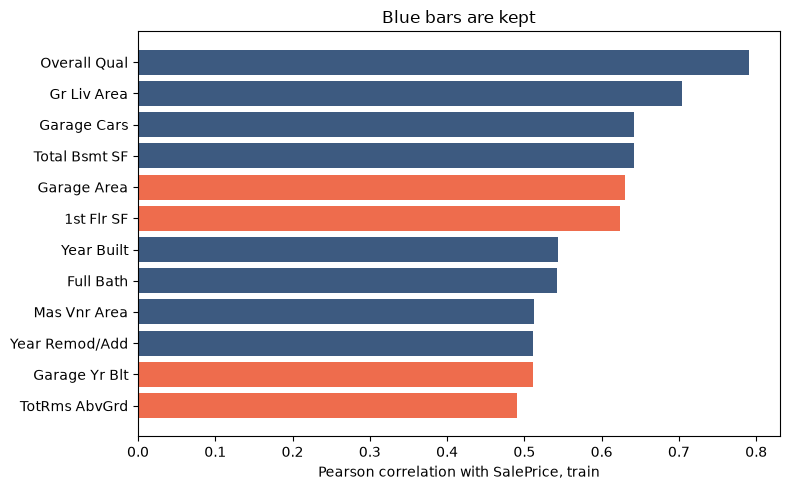

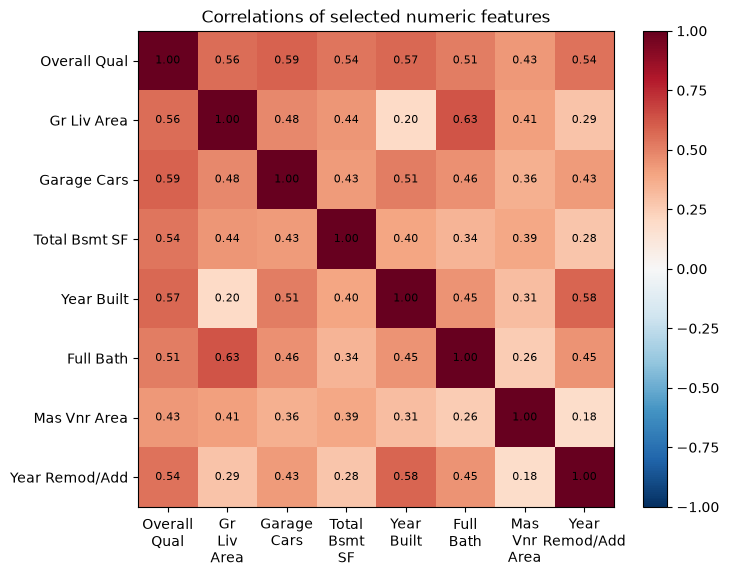

In [14]:
top_corr = corr_with_price.head(12).iloc[::-1]
colors = ["#ee6c4d" if name not in selected_numeric else "#3d5a80" for name in top_corr.index]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_corr.index, top_corr.values, color=colors)
ax.set_xlabel("Pearson correlation with SalePrice, train")
ax.set_title("Blue bars are kept")
fig.tight_layout()
plt.show()

chosen_matrix = X_train[selected_numeric].corr()
fig, ax = plt.subplots(figsize=(8.5, 7))
image = ax.imshow(chosen_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(selected_numeric)), [name.replace(" ", "\n") for name in selected_numeric])
ax.set_yticks(range(len(selected_numeric)), selected_numeric)
for i in range(len(selected_numeric)):
    for j in range(len(selected_numeric)):
        ax.text(j, i, f"{chosen_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(image, ax=ax, fraction=0.046)
ax.set_title("Correlations of selected numeric features")
fig.subplots_adjust(left=0.22, right=0.9, bottom=0.22, top=0.9)
plt.show()


**Висновок.** У модель увійшли `Overall Qual`, `Gr Liv Area`, `Garage Cars`, `Total Bsmt SF`, `Year Built`, `Year Remod/Add`, `Full Bath`, `Mas Vnr Area`.

Дублікати прибрано: `Garage Area` (є `Garage Cars`, r ≈ 0.89), `1st Flr SF` (є `Total Bsmt SF`, r ≈ 0.83), `Garage Yr Blt` (є `Year Built`, r ≈ 0.82). `TotRms AbvGrd` і `Fireplaces` слабші за поріг 0.5. `Order` і `PID` — ідентифікатори.


### Категорії

Neighborhood і Bldg Type не мають природного порядку, тому кодую їх one-hot. Kitchen Qual і Exter Qual мають порядок Po, Fa, TA, Gd, Ex, тому кодую їх порядковими числами. House Style не беру, бо поверховість уже частково є в житловій площі.


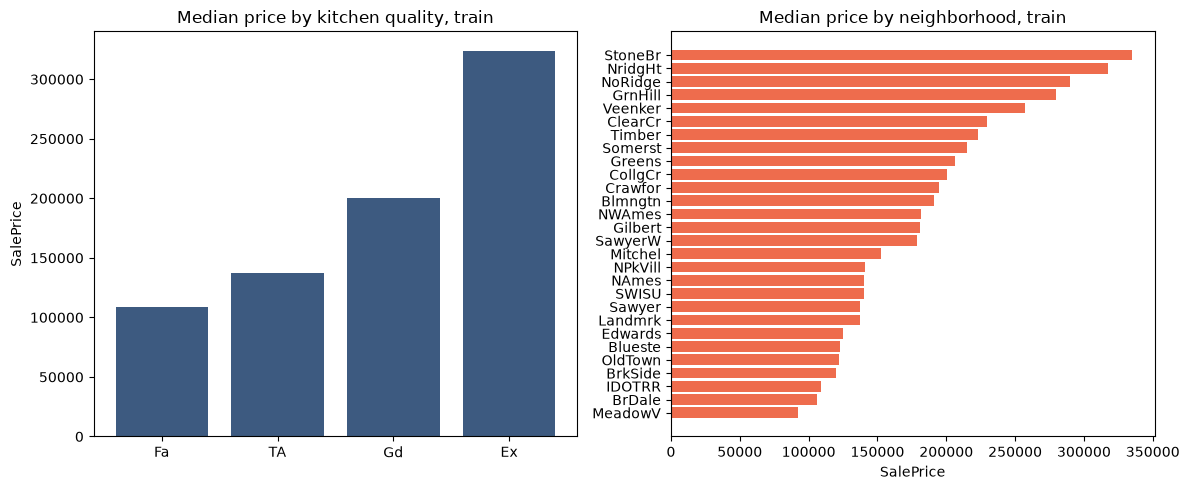

Медіанна ціна за Kitchen Qual на Train:
Kitchen Qual
Po         NaN
Fa    108500.0
TA    136905.0
Gd    200000.0
Ex    324000.0
Name: SalePrice, dtype: float64


In [15]:
nominal_features = ["Neighborhood", "Bldg Type"]
ordinal_features = ["Kitchen Qual", "Exter Qual"]
quality_levels = ["Po", "Fa", "TA", "Gd", "Ex"]

train_prices = X_train.copy()
train_prices["SalePrice"] = y_train
kitchen_median = (
    train_prices.groupby("Kitchen Qual")["SalePrice"]
    .median()
    .reindex(quality_levels)
)
area_median = train_prices.groupby("Neighborhood")["SalePrice"].median().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(kitchen_median.index, kitchen_median.values, color="#3d5a80")
axes[0].set_title("Median price by kitchen quality, train")
axes[0].set_ylabel("SalePrice")

axes[1].barh(area_median.index, area_median.values, color="#ee6c4d")
axes[1].set_title("Median price by neighborhood, train")
axes[1].set_xlabel("SalePrice")
fig.tight_layout()
plt.show()

print("Медіанна ціна за Kitchen Qual на Train:")
print(kitchen_median.round(0))


**Висновок.** На Train медіанна ціна кухні зростає від Fa до Ex. Рівня Po у Train немає. Райони теж дають різну ціну, тому Neighborhood лишаю.

Пропуски в обраних числових колонках заповнюю медіаною Train.


In [16]:
feature_frame_columns = selected_numeric + nominal_features + ordinal_features

X_train = X_train[feature_frame_columns].copy()
X_val = X_val[feature_frame_columns].copy()
X_test = X_test[feature_frame_columns].copy()

numeric_medians = X_train[selected_numeric].median()
categorical_modes = X_train[nominal_features + ordinal_features].mode().iloc[0]

for frame in (X_train, X_val, X_test):
    frame[selected_numeric] = frame[selected_numeric].fillna(numeric_medians)
    frame[nominal_features + ordinal_features] = frame[
        nominal_features + ordinal_features
    ].fillna(categorical_modes)

print("Пропусків після заповнення:", int(X_train.isna().sum().sum() + X_val.isna().sum().sum() + X_test.isna().sum().sum()))
print("Медіани Train для числових ознак:")
print(numeric_medians.round(2))


Пропусків після заповнення: 0
Медіани Train для числових ознак:
Overall Qual         6.0
Gr Liv Area       1440.0
Garage Cars          2.0
Total Bsmt SF      984.0
Year Built        1972.0
Full Bath            2.0
Mas Vnr Area         0.0
Year Remod/Add    1992.0
dtype: float64


## 1.4 Кодування категорій

Якщо на Validation або Test з'являється категорія, якої не було в Train, one-hot не створює нову колонку і ставить нулі. Порядкова шкала взята зі словника Ames, тому рівень Po отримує свій ранг навіть без прикладів у Train. Мітка, якої немає і в словнику, отримує код -1.

Target encoding не беру. Він підставляє середню ціну категорії, тож легко підглядає в ціль. Для рідкісних районів цю середню треба рахувати через K-fold, інакше буде витік.


In [17]:
one_hot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
one_hot.fit(X_train[nominal_features])

ordinal = OrdinalEncoder(
    categories=[quality_levels, quality_levels],
    handle_unknown="use_encoded_value",
    unknown_value=-1,
)
ordinal.fit(X_train[ordinal_features])


def unseen_levels(frame, columns):
    report = {}
    for column in columns:
        known = set(X_train[column].unique())
        extra = sorted(set(frame[column].unique()) - known)
        if extra:
            report[column] = extra
    return report


print("Рівні Validation, яких не було в Train:", unseen_levels(X_val, nominal_features + ordinal_features))
print("Рівні Test, яких не було в Train:", unseen_levels(X_test, nominal_features + ordinal_features))
print("Кількість one-hot колонок:", len(one_hot.get_feature_names_out(nominal_features)))


Рівні Validation, яких не було в Train: {'Kitchen Qual': ['Po']}
Рівні Test, яких не було в Train: {}
Кількість one-hot колонок: 33


In [18]:
def encode_nominal(frame):
    encoded = one_hot.transform(frame[nominal_features])
    names = one_hot.get_feature_names_out(nominal_features)
    return pd.DataFrame(encoded, columns=names, index=frame.index)


def encode_ordinal(frame):
    encoded = ordinal.transform(frame[ordinal_features])
    return pd.DataFrame(encoded, columns=ordinal_features, index=frame.index)


X_train_nominal = encode_nominal(X_train)
X_val_nominal = encode_nominal(X_val)
X_test_nominal = encode_nominal(X_test)

X_train_ordinal = encode_ordinal(X_train)
X_val_ordinal = encode_ordinal(X_val)
X_test_ordinal = encode_ordinal(X_test)

print(X_train_ordinal.head())


      Kitchen Qual  Exter Qual
1322           2.0         2.0
2475           3.0         3.0
2090           3.0         3.0
2733           2.0         2.0
2881           2.0         1.0


**Висновок.** На Validation є `Kitchen Qual = Po`, у Train його не було. Такий рядок отримує код 0, а не нову колонку.


## 1.5 Масштабування

Площі, роки і бали якості мають різний масштаб, тому числові й порядкові колонки стандартизую. Середнє і стандартне відхилення беру з Train і ними переводжу Validation і Test. One-hot не стандартизую, бо там уже значення 0 і 1.


In [19]:
scale_columns = selected_numeric + ordinal_features

scaler = StandardScaler()
scaler.fit(pd.concat([X_train[selected_numeric], X_train_ordinal], axis=1))


def scale_numeric(frame_numeric, frame_ordinal):
    block = pd.concat([frame_numeric[selected_numeric], frame_ordinal], axis=1)
    scaled = scaler.transform(block)
    return pd.DataFrame(scaled, columns=scale_columns, index=frame_numeric.index)


X_train_scaled = scale_numeric(X_train, X_train_ordinal)
X_val_scaled = scale_numeric(X_val, X_val_ordinal)
X_test_scaled = scale_numeric(X_test, X_test_ordinal)

print(X_train_scaled.mean().round(6).head())
print(X_train_scaled.std(ddof=0).round(6).head())


Overall Qual    -0.0
Gr Liv Area     -0.0
Garage Cars     -0.0
Total Bsmt SF   -0.0
Year Built      -0.0
dtype: float64
Overall Qual     1.0
Gr Liv Area      1.0
Garage Cars      1.0
Total Bsmt SF    1.0
Year Built       1.0
dtype: float64


In [20]:
X_train_ready = pd.concat([X_train_scaled, X_train_nominal], axis=1)
X_val_ready = pd.concat([X_val_scaled, X_val_nominal], axis=1)
X_test_ready = pd.concat([X_test_scaled, X_test_nominal], axis=1)

feature_names = X_train_ready.columns.to_list()

X_train_np = X_train_ready.to_numpy(dtype=float)
X_val_np = X_val_ready.to_numpy(dtype=float)
X_test_np = X_test_ready.to_numpy(dtype=float)
y_train_np = y_train.to_numpy(dtype=float)
y_val_np = y_val.to_numpy(dtype=float)
y_test_np = y_test.to_numpy(dtype=float)

print("Train:", X_train_np.shape)
print("Validation:", X_val_np.shape)
print("Test:", X_test_np.shape)
print("Ознак у матриці:", len(feature_names))


Train: (1758, 43)
Validation: (586, 43)
Test: (586, 43)
Ознак у матриці: 43


## Підсумок етапу 1

SalePrice має правий хвіст, але в модель іде в доларах. Кореляції для відбору, медіану, кодування і масштабування пораховано тільки на Train, щоб не було витоку. Вісім числових ознак залишено, три дублікати прибрано. Район і тип будівлі закодовано one-hot, якості кухні й фасаду — порядковою шкалою. Матриці для Train, Validation і Test готові до навчання.


---

# Етап 2. Лінійна регресія на NumPy

Прогноз дорівнює добутку матриці ознак на ваги плюс вільний член.

Функція втрат — середній квадрат похибки, поділений на 2. Двійка потрібна, щоб вона скоротилась у градієнті.

Градієнт за вагами — це ознаки, помножені на похибку і поділені на число рядків. Градієнт за вільним членом — середня похибка.

На кроці навчання від ваг віднімається learning rate, помножений на градієнт. Так само оновлюється вільний член.

Вартість і градієнт рахуються добутками матриць, без циклу по об'єктах.


In [21]:
def mean_squared_error(y_pred, y):
    """Half mean squared error: J = (1 / (2 m)) * sum((y_pred - y)^2). Same as MSE / 2."""
    residual = y_pred - y
    with np.errstate(over="ignore"):
        return np.dot(residual, residual) / (2.0 * y.shape[0])


class LinearRegression:
    """Prediction is Xw + b."""

    def __init__(self, n_features):
        self.w = np.zeros(n_features, dtype=float)
        self.b = 0.0

    def predict(self, X):
        return X @ self.w + self.b

    def loss(self, X, y):
        return mean_squared_error(self.predict(X), y)

    def gradients(self, X, y):
        residual = self.predict(X) - y
        m = y.shape[0]
        dw = (X.T @ residual) / m
        db = np.sum(residual) / m
        return dw, db

    def update(self, dw, db, learning_rate):
        self.w = self.w - learning_rate * dw
        self.b = self.b - learning_rate * db


In [22]:
# Finite-difference check of the gradient. The loop only walks coordinates.
rng = np.random.default_rng(0)
X_toy = rng.normal(size=(40, 3))
true_w = np.array([1.5, -2.0, 0.5])
y_toy = X_toy @ true_w + 0.3

check = LinearRegression(X_toy.shape[1])
check.w = np.array([0.2, -0.4, 0.1])
check.b = 0.05
analytic_dw, analytic_db = check.gradients(X_toy, y_toy)

eps = 1e-6
numeric_dw = np.empty_like(check.w)
saved_w, saved_b = check.w.copy(), check.b
for index in range(check.w.size):
    step = np.zeros_like(check.w)
    step[index] = eps
    check.w = saved_w + step
    loss_plus = check.loss(X_toy, y_toy)
    check.w = saved_w - step
    loss_minus = check.loss(X_toy, y_toy)
    numeric_dw[index] = (loss_plus - loss_minus) / (2.0 * eps)

check.w = saved_w
check.b = saved_b + eps
loss_plus = check.loss(X_toy, y_toy)
check.b = saved_b - eps
loss_minus = check.loss(X_toy, y_toy)
numeric_db = (loss_plus - loss_minus) / (2.0 * eps)
check.w, check.b = saved_w, saved_b

print("max |Δw|:", np.max(np.abs(analytic_dw - numeric_dw)))
print("|Δb|:", abs(analytic_db - numeric_db))

model = LinearRegression(X_train_np.shape[1])
print("Прогноз на Train:", model.predict(X_train_np).shape)


max |Δw|: 2.5193058750261343e-10
|Δb|: 2.3595181364299833e-11
Прогноз на Train: (1758,)


**Висновок.** Аналітичний градієнт збігається з перевіркою скінченними різницями. Похідні за вагами і за вільним членом записані правильно.


### Нормальне рівняння

До матриці ознак додаю стовпець одиниць: $\tilde{X} = [X \mid \mathbf{1}]$. Функція втрат:

$$
J(w) = \frac{1}{2m}\,(\tilde{X}w - y)^\top(\tilde{X}w - y)
$$

У мінімумі $\nabla J = 0$:

$$
\tilde{X}^\top \tilde{X}\, w = \tilde{X}^\top y
\qquad\Rightarrow\qquad
w = (\tilde{X}^\top \tilde{X})^{-1}\tilde{X}^\top y
$$

Це один крок без learning rate. Обертання коштує $O(n^3)$. Єдиного розв'язку немає, якщо колонки лінійно залежні.

GD з нульовою ініціалізацією дає розв'язок мінімальної норми серед усіх мінімумів $J$, тому лінійна залежність one-hot із вільним членом йому не шкодить — на відміну від прямого обертання $\tilde{X}^\top\tilde{X}$.


In [23]:
design = np.column_stack([X_train_np, np.ones(X_train_np.shape[0])])
singular_values = np.linalg.svd(design, compute_uv=False)
print("Найменші сингулярні значення [X | 1]:", singular_values[-3:])


Найменші сингулярні значення [X | 1]: [1.00188779e+00 1.24075929e-14 3.52507944e-15]


**Висновок.** Близьких до нуля сингулярних значень два: близько 1.2e-14 і 3.5e-15. Це дві лінійні залежності: сума one-hot району дорівнює одиниці, і сума one-hot типу будівлі теж дорівнює одиниці, бо в матриці вже є вільний член. Нормальне рівняння тут не дає єдиного розв'язку, тому далі модель учиться лише градієнтним спуском.


---

# Етап 3. Три варіанти градієнтного спуску

Градієнт у всіх трьох методів один і той самий. Відрізняється лише те, на якій частині Train він рахується за крок. Batch GD бере весь Train. Mini-batch GD бере 64 рядки. SGD бере один рядок.

Цикл перебирає епохи і батчі. Вартість і градієнт кожного батча рахуються матрично.

Learning rate обираю за найменшою втратою на Validation. Зупинку за фіксованою кількістю епох (80 на графіку, 20 під час підбору α) обираю свідомо: так однаково порівнюю три методи і не підганяю критерій під кожен окремо. Для метрик лишаю ваги з епохи з найкращим Validation. Test у виборі learning rate не використовую.


In [24]:
def r_squared(y, y_pred):
    residual_ss = np.sum((y - y_pred) ** 2)
    total_ss = np.sum((y - np.mean(y)) ** 2)
    return 1.0 - residual_ss / total_ss


def rmse(y, y_pred):
    return np.sqrt(np.mean((y - y_pred) ** 2))


def fit_gd(X, y, learning_rate, n_epochs, batch_size, seed=42, X_val=None, y_val=None):
    """A batch_size of at least the row count is Batch GD. A batch_size of 1 is SGD."""
    model = LinearRegression(X.shape[1])
    m = X.shape[0]
    step = m if batch_size >= m else batch_size
    rng = np.random.default_rng(seed)
    train_loss, val_loss = [], []
    best_w, best_b, best_val = model.w.copy(), model.b, np.inf

    for _ in range(n_epochs):
        order = np.arange(m) if step == m else rng.permutation(m)
        for start in range(0, m, step):
            batch = order[start:start + step]
            dw, db = model.gradients(X[batch], y[batch])
            model.update(dw, db, learning_rate)
        current = model.loss(X, y)
        if not np.isfinite(current) or (train_loss and current > min(train_loss) * 8):
            break
        train_loss.append(current)
        if X_val is not None:
            current_val = model.loss(X_val, y_val)
            val_loss.append(current_val)
            if np.isfinite(current_val) and current_val < best_val:
                best_val = current_val
                best_w, best_b = model.w.copy(), model.b

    model.w, model.b = best_w, best_b
    return model, np.asarray(train_loss), np.asarray(val_loss)


def select_learning_rate(X, y, X_val, y_val, batch_size, candidates, n_epochs=20):
    best_lr, best_score = None, np.inf
    for lr in candidates:
        _, train_loss, val_loss = fit_gd(
            X, y, lr, n_epochs, batch_size, X_val=X_val, y_val=y_val
        )
        if train_loss.size < n_epochs or val_loss.size == 0 or not np.isfinite(val_loss).any():
            print(f"  α={lr:g}: розбігся")
            continue
        score = float(np.min(val_loss))
        print(f"  α={lr:g}: min J на Validation = {score:.3e}")
        if score < best_score:
            best_score, best_lr = score, lr
    if best_lr is None:
        raise RuntimeError("Жоден learning rate не збігся")
    return best_lr


Підбір α, 20 епох, критерій — Validation
Batch GD
  α=0.1: min J на Validation = 9.414e+08
  α=0.2: min J на Validation = 8.643e+08
  α=0.5: розбігся
  α=1: розбігся
  обрано α=0.2
Mini-batch GD
  α=0.1: min J на Validation = 7.038e+08
  α=0.2: min J на Validation = 6.714e+08
  α=0.5: розбігся
  α=1: розбігся
  α=2: розбігся
  обрано α=0.2
SGD


  α=0.001: min J на Validation = 7.215e+08
  α=0.005: min J на Validation = 6.475e+08
  α=0.01: min J на Validation = 6.547e+08
  α=0.05: розбігся
  α=0.1: розбігся
  обрано α=0.005


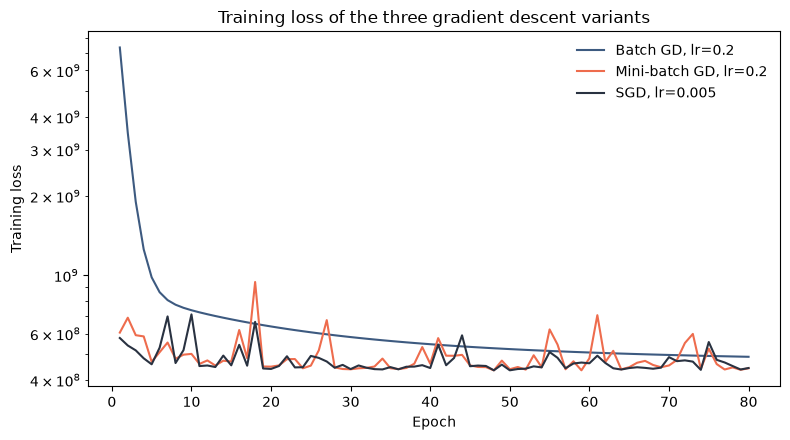

In [25]:
schedules = [
    ("Batch GD", X_train_np.shape[0], [0.1, 0.2, 0.5, 1.0]),
    ("Mini-batch GD", 64, [0.1, 0.2, 0.5, 1.0, 2.0]),
    ("SGD", 1, [0.001, 0.005, 0.01, 0.05, 0.1]),
]

print("Підбір α, 20 епох, критерій — Validation")
chosen_lr = {}
for name, batch_size, grid in schedules:
    print(name)
    chosen_lr[name] = select_learning_rate(
        X_train_np, y_train_np, X_val_np, y_val_np, batch_size, grid
    )
    print(f"  обрано α={chosen_lr[name]:g}")

n_epochs = 80
runs = {}
for name, batch_size, _ in schedules:
    model, train_loss, val_loss = fit_gd(
        X_train_np,
        y_train_np,
        chosen_lr[name],
        n_epochs,
        batch_size,
        X_val=X_val_np,
        y_val=y_val_np,
    )
    runs[name] = {
        "model": model,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "lr": chosen_lr[name],
        "batch_size": batch_size,
    }

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = {"Batch GD": "#3d5a80", "Mini-batch GD": "#ee6c4d", "SGD": "#293241"}
for name, run in runs.items():
    epochs = np.arange(1, run["train_loss"].size + 1)
    ax.plot(
        epochs,
        run["train_loss"],
        color=colors[name],
        label=f"{name}, lr={run['lr']:g}",
    )
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("Training loss")
ax.set_title("Training loss of the three gradient descent variants")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


**Висновок.** Batch GD найстабільніший, бо за епоху робить один крок на всьому Train, і крива втрати гладка. Він же найповільніший: на 80-й епосі втрата ще трохи вища, ніж у двох інших методів.

Найвищі сплески дає Mini-batch з learning rate 0.2: окремі епохи підскакують майже вдвічі. SGD теж коливається, але його learning rate дорівнює 0.005, тому амплітуда менша. Learning rate 0.01 для SGD уже трохи гірший, а 0.05 розбігається. Для Batch і Mini-batch learning rate 0.5 теж розбігається, тож обрані 0.2 лежать усередині сітки, а не на її краю.

Менший батч робить більше кроків за епоху, тому втрата падає швидше. Якщо learning rate при цьому не зменшити, градієнт стає шумним і крива починає стрибати.


---

# Етап 4. Коефіцієнт детермінації

R² дорівнює одиниці мінус відношення суми квадратів похибок до суми квадратів відхилень ціни від її середнього. Він показує, яку частку розкиду ціни модель знімає порівняно з прогнозом «завжди середнє». Одиниця означає, що похибок немає. Нуль означає, що модель не краща за середнє.

R² буває від'ємним, коли сума квадратів похибок більша, ніж у константи-середнього. Для точного МНК-оптимуму з вільним членом на Train R² ≥ 0, бо прогноз середнім — окремий випадок такої моделі. Після GD (недозбіжність, рання зупинка) R² може бути від'ємним і на Train. На Validation/Test від'ємний R² можливий завжди.


In [26]:
print(f"{'метод':<16} {'α':>8} {'R² train':>10} {'R² val':>10} {'R² test':>10} {'RMSE test, $':>14}")
for name, run in runs.items():
    model = run["model"]
    scores = [
        r_squared(y, model.predict(X))
        for X, y in (
            (X_train_np, y_train_np),
            (X_val_np, y_val_np),
            (X_test_np, y_test_np),
        )
    ]
    run["r2"] = scores
    test_rmse = rmse(y_test_np, model.predict(X_test_np))
    run["rmse_test"] = test_rmse
    print(
        f"{name:<16} {run['lr']:8g} {scores[0]:10.3f} {scores[1]:10.3f} "
        f"{scores[2]:10.3f} {test_rmse:14,.0f}"
    )

best_name = min(runs, key=lambda name: np.min(runs[name]["val_loss"]))
best_model = runs[best_name]["model"]
print("Найкращий за Validation:", best_name)


метод                   α   R² train     R² val    R² test   RMSE test, $
Batch GD              0.2      0.838      0.782      0.851         31,829
Mini-batch GD         0.2      0.852      0.814      0.847         32,345
SGD                 0.005      0.837      0.818      0.827         34,343
Найкращий за Validation: SGD


**Висновок.** На Test усі три методи дають R² 0.83–0.85 і RMSE близько 32–34 тис. $. Розрив Train/Test ≈ 0.01, Test не гірший за Train — перенавчання немає. На Validation R² помітно нижчий, 0.78–0.82, ніж на Test. Це схоже на випадковість розбиття, тому різницю між методами за Validation не варто читати як істотну. За якістю методи близькі.


---

# Етап 5. Статистичні припущення

Залишок — це справжня ціна мінус прогноз. Дивлюсь залишки найкращої за Validation моделі на Train.


Середній залишок і std по діапазонах прогнозу:
  прогноз ≈ 93,190 $   mean e = 6,193   std e = 18,288
  прогноз ≈ 123,558 $   mean e = 1,602   std e = 16,314
  прогноз ≈ 143,095 $   mean e = -618   std e = 15,822
  прогноз ≈ 166,264 $   mean e = -4,176   std e = 20,932
  прогноз ≈ 195,392 $   mean e = -6,763   std e = 27,521
  прогноз ≈ 228,874 $   mean e = -9,025   std e = 30,650
  прогноз ≈ 303,168 $   mean e = 13,059   std e = 59,494
Шапіро–Уілк: W = 0.8653, p = 2.043e-36


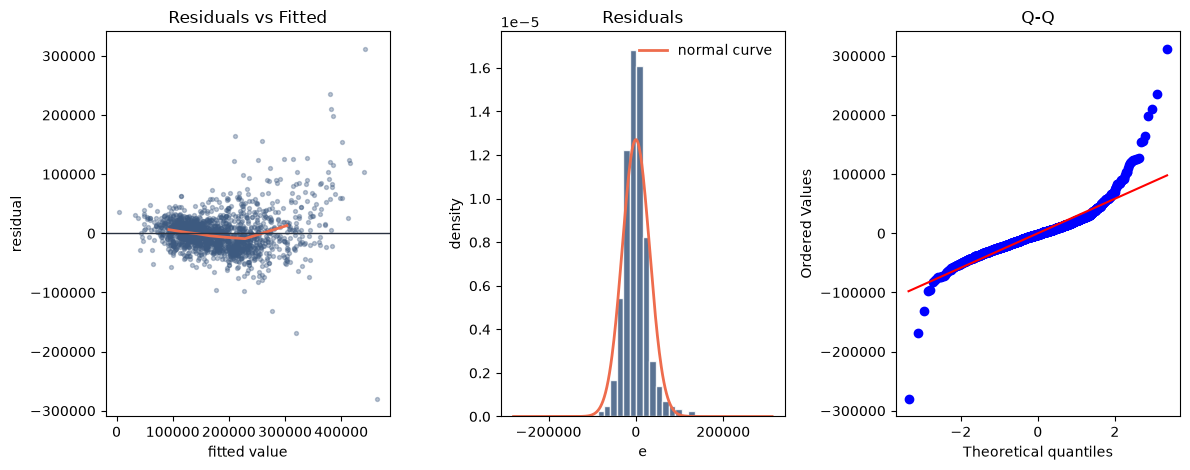

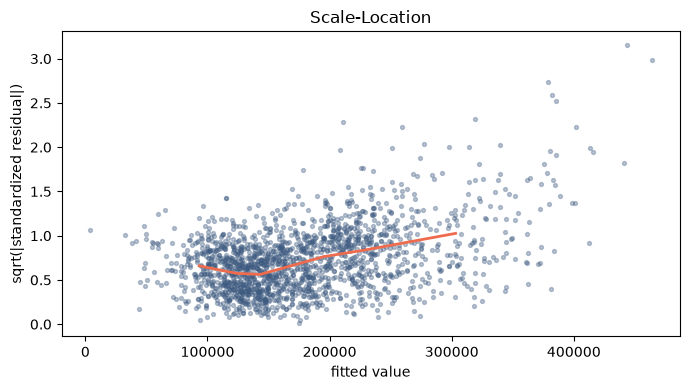

In [27]:
from scipy import stats

fitted = best_model.predict(X_train_np)
resid = y_train_np - fitted

edges = np.quantile(fitted, np.linspace(0, 1, 8))
bin_center, bin_mean, bin_std, bin_scale = [], [], [], []
for i in range(len(edges) - 1):
    if i < len(edges) - 2:
        mask = (fitted >= edges[i]) & (fitted < edges[i + 1])
    else:
        mask = (fitted >= edges[i]) & (fitted <= edges[i + 1])
    bin_center.append(float(fitted[mask].mean()))
    bin_mean.append(float(resid[mask].mean()))
    bin_std.append(float(resid[mask].std()))
    bin_scale.append(float(np.mean(np.sqrt(np.abs(resid[mask] / resid.std())))))

print("Середній залишок і std по діапазонах прогнозу:")
for center, mean, std in zip(bin_center, bin_mean, bin_std):
    print(f"  прогноз ≈ {center:,.0f} $   mean e = {mean:,.0f}   std e = {std:,.0f}")

shapiro_stat, shapiro_p = stats.shapiro(resid)
print(f"Шапіро–Уілк: W = {shapiro_stat:.4f}, p = {shapiro_p:.3e}")

fig, axes = plt.subplots(1, 3, figsize=(12, 4.8))
axes[0].scatter(fitted, resid, s=8, alpha=0.35, color="#3d5a80")
axes[0].plot(bin_center, bin_mean, color="#ee6c4d", linewidth=2)
axes[0].axhline(0, color="#293241", linewidth=1)
axes[0].set_xlabel("fitted value")
axes[0].set_ylabel("residual")
axes[0].set_title("Residuals vs Fitted")

axes[1].hist(resid, bins=40, density=True, color="#3d5a80", edgecolor="white", alpha=0.85)
normal_curve(resid, axes[1])
axes[1].set_title("Residuals")
axes[1].set_xlabel("e")
axes[1].set_ylabel("density")

stats.probplot(resid, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q")
fig.tight_layout()
plt.show()

std_resid = resid / resid.std()
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(fitted, np.sqrt(np.abs(std_resid)), s=8, alpha=0.35, color="#3d5a80")
ax.plot(bin_center, bin_scale, color="#ee6c4d", linewidth=2)
ax.set_xlabel("fitted value")
ax.set_ylabel("sqrt(|standardized residual|)")
ax.set_title("Scale-Location")
fig.tight_layout()
plt.show()


VIF числових і порядкових ознак (Train):
  Overall Qual     3.11
  Exter Qual       2.81
  Gr Liv Area      2.51
  Kitchen Qual     2.45
  Year Built       2.32
  Full Bath        2.13
  Year Remod/Add   2.00
  Garage Cars      1.83
  Total Bsmt SF    1.57
  Mas Vnr Area     1.39


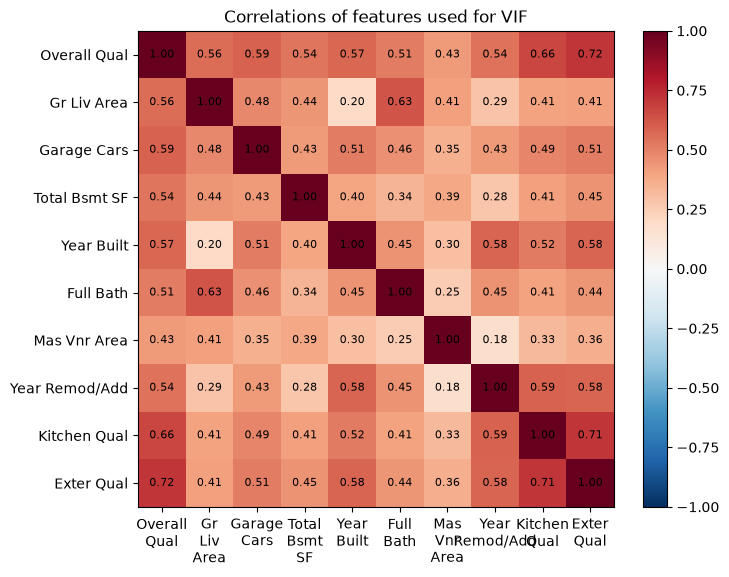

Коефіцієнти при стандартизованих ознаках, $ за 1 std:
  Overall Qual         15,302
  Gr Liv Area          17,440
  Garage Cars           9,808
  Total Bsmt SF         2,760
  Year Built           13,671
  Full Bath             2,144
  Mas Vnr Area          1,359
  Year Remod/Add        3,841
  Kitchen Qual         10,148
  Exter Qual            5,509


In [28]:
def variance_inflation(X):
    scores = np.empty(X.shape[1])
    for feature in range(X.shape[1]):
        target = X[:, feature]
        others = np.column_stack([np.ones(X.shape[0]), np.delete(X, feature, axis=1)])
        coef, *_ = np.linalg.lstsq(others, target, rcond=None)
        predicted = others @ coef
        ss_res = np.sum((target - predicted) ** 2)
        ss_tot = np.sum((target - target.mean()) ** 2)
        r2 = 1.0 - ss_res / ss_tot
        scores[feature] = np.inf if r2 >= 1.0 - 1e-10 else 1.0 / (1.0 - r2)
    return scores


numeric_block = X_train_np[:, : len(selected_numeric) + len(ordinal_features)]
numeric_names = feature_names[: numeric_block.shape[1]]
vif = variance_inflation(numeric_block)
order = np.argsort(vif)[::-1]
print("VIF числових і порядкових ознак (Train):")
for index in order:
    print(f"  {numeric_names[index]:<16} {vif[index]:.2f}")

corr = np.corrcoef(numeric_block, rowvar=False)
fig, ax = plt.subplots(figsize=(8.5, 7))
image = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_names)), [name.replace(" ", "\n") for name in numeric_names])
ax.set_yticks(range(len(numeric_names)), numeric_names)
for i in range(len(numeric_names)):
    for j in range(len(numeric_names)):
        ax.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(image, ax=ax, fraction=0.046)
ax.set_title("Correlations of features used for VIF")
fig.subplots_adjust(left=0.22, right=0.9, bottom=0.22, top=0.9)
plt.show()

print("Коефіцієнти при стандартизованих ознаках, $ за 1 std:")
for name, weight in zip(numeric_names, best_model.w[: len(numeric_names)]):
    print(f"  {name:<16} {weight:10,.0f}")


**Лінійність порушується слабо.** Середні залишки по діапазонах прогнозу йдуть приблизно так: +6 тис., +2 тис., −1 тис., −4 тис., −7 тис., −9 тис., +13 тис. Це U-подібний вигин. Логарифм ціни прибрав би його. Для типових будинків пряма ще придатна, на краях ціни вона систематично помиляється.

**Нормальність залишків порушується.** Пік гістограми вужчий за нормальну криву, хвости на Q-Q загинаються вгору і вниз, Шапіро–Уілк p ≈ 0. Це наслідок правого хвоста `SalePrice`. Інтервали, які спираються на нормальні похибки, тут ненадійні.

**Гомоскедастичність порушується.** Std залишків зростає з ≈ 16 тис. у середньому сегменті до ≈ 59 тис. у дорогих будинків, хмара на Scale-Location ширшає після 300 тис. Це означає, що прогноз точніший для типових будинків і грубший для дорогих.

**Мультиколінеарність числових ознак слабка.** VIF від 1.4 до 3.1, усі нижче 5. Коефіцієнти одного знака: близько 17 тис. $ за одне стандартне відхилення житлової площі і 15 тис. за якість. Ваги не роздуті.

Окремо one-hot району і типу будівлі разом із вільним членом лінійно залежні, тож окремий коефіцієнт району не має єдиного значення. На прогноз це майже не впливає: R² на Test близько 0.83.


---

# Етап 6. Експеримент A. Вплив масштабування

Той самий Mini-batch GD з батчем 64 рядків запускаю на сирих ознаках і на стандартизованих. Learning rate для кожного варіанту підбираю окремо за Validation.


cond(X), raw numeric: 10564.32133448388
cond(X^T X), raw numeric: 111604885.25816514
cond(X), scaled numeric: 4.924855880049028
cond(X^T X), scaled numeric: 24.254205439253408
Сирі ознаки
  α=1e-08: min J на Validation = 1.560e+09
  α=1e-07: min J на Validation = 1.537e+09
  α=1e-06: розбігся
  α=1e-05: розбігся
  α=0.0001: розбігся
обрано α=1e-07
Стандартизовані ознаки
  α=0.2: min J на Validation = 6.714e+08
  α=0.5: розбігся
  α=1: розбігся
  α=2: розбігся
  α=5: розбігся
обрано α=0.2
J наприкінці: сирі 1.063e+09 стандартизовані 4.432e+08
R² Validation: сирі 0.562 стандартизовані 0.814


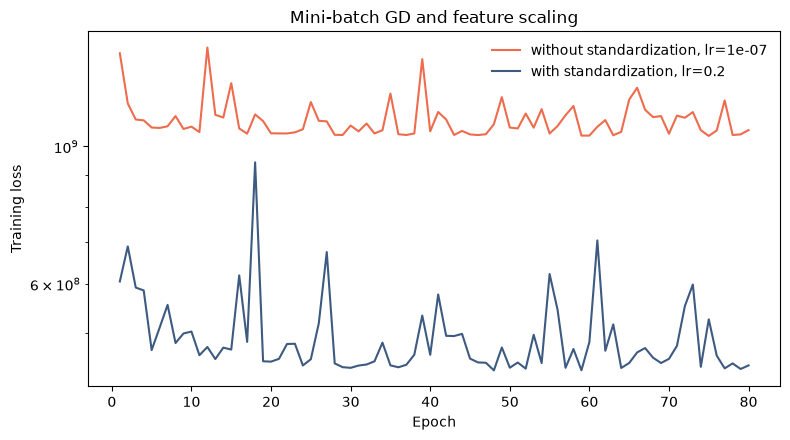

In [29]:
def design_raw(frame, ordinal_frame, nominal_frame):
    return np.column_stack([
        frame[selected_numeric].to_numpy(dtype=float),
        ordinal_frame.to_numpy(dtype=float),
        nominal_frame.to_numpy(dtype=float),
    ])


X_train_raw = design_raw(X_train, X_train_ordinal, X_train_nominal)
X_val_raw = design_raw(X_val, X_val_ordinal, X_val_nominal)

# Convergence depends on cond(Hessian) ≈ cond(X^T X / m) ≈ cond(X)^2.
numeric_width = len(selected_numeric) + len(ordinal_features)
X_raw_num = X_train_raw[:, :numeric_width]
X_scaled_num = X_train_np[:, :numeric_width]
print("cond(X), raw numeric:", float(np.linalg.cond(X_raw_num)))
print("cond(X^T X), raw numeric:", float(np.linalg.cond(X_raw_num.T @ X_raw_num)))
print("cond(X), scaled numeric:", float(np.linalg.cond(X_scaled_num)))
print("cond(X^T X), scaled numeric:", float(np.linalg.cond(X_scaled_num.T @ X_scaled_num)))

print("Сирі ознаки")
raw_grid = [1e-8, 1e-7, 1e-6, 1e-5, 1e-4]
raw_lr = select_learning_rate(
    X_train_raw, y_train_np, X_val_raw, y_val_np, 64, raw_grid, n_epochs=20
)
print(f"обрано α={raw_lr:g}")

print("Стандартизовані ознаки")
scaled_lr = select_learning_rate(
    X_train_np, y_train_np, X_val_np, y_val_np, 64, [0.2, 0.5, 1.0, 2.0, 5.0], n_epochs=20
)
print(f"обрано α={scaled_lr:g}")

raw_model, raw_loss, _ = fit_gd(
    X_train_raw, y_train_np, raw_lr, 80, 64, X_val=X_val_raw, y_val=y_val_np
)
scaled_model, scaled_loss, _ = fit_gd(
    X_train_np, y_train_np, scaled_lr, 80, 64, X_val=X_val_np, y_val=y_val_np
)
print("J наприкінці: сирі", f"{raw_loss[-1]:.3e}", "стандартизовані", f"{scaled_loss[-1]:.3e}")
print(
    "R² Validation: сирі",
    round(r_squared(y_val_np, raw_model.predict(X_val_raw)), 3),
    "стандартизовані",
    round(r_squared(y_val_np, scaled_model.predict(X_val_np)), 3),
)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(np.arange(1, raw_loss.size + 1), raw_loss, color="#ee6c4d", label=f"without standardization, lr={raw_lr:g}")
ax.plot(np.arange(1, scaled_loss.size + 1), scaled_loss, color="#3d5a80", label=f"with standardization, lr={scaled_lr:g}")
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("Training loss")
ax.set_title("Mini-batch GD and feature scaling")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


**Висновок.** Без стандартизації learning rate дорівнює 1e-7, зі стандартизацією — 0.2. Обидва значення всередині сітки: для сирих ознак 1e-6 уже розбігається, для стандартизованих — 0.5. За 80 епох сирі ознаки дають R² на Validation 0.56, стандартизовані — 0.81.

Без масштабування лінії рівня функції втрат — витягнуті еліпси. Збіжність GD залежить від числа обумовленості гесіана $X^\top X / m$, а воно приблизно $\mathrm{cond}(X)^2$. Для сирого числового блоку $\mathrm{cond}(X)\sim 10^4$, тож $\mathrm{cond}(X^\top X)\sim 10^8$: градієнт великий уздовж ознак із великим розкидом і малий уздовж дрібних. Один крок не може швидко рухати дрібні ознаки і водночас не зривати великі, тому learning rate доводиться брати дуже малим. Після стандартизації $\mathrm{cond}(X)$ падає приблизно до 5, $\mathrm{cond}(X^\top X)$ — до порядку десятків, контури втрат стають значно круглішими, і той самий алгоритм з більшим кроком доходить ближче до мінімуму.


часосову залежність перевірка 